# Exploratory Data Analysis (EDA)
We examine distributions, fraud rates across categorical features, and temporal patterns before touching the data for modelling. Good EDA shapes better feature engineering.

## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Style settings
DARK = {
    "bg": "#0F1117", "panel": "#1A1D27", "grid": "#252836",
    "text": "#E8EAF0", "sub": "#8890A4", "blue": "#4F8EF7",
    "red": "#F7614F", "green": "#4FD1A5", "gold": "#F7C84F", "purple": "#A78BFA",
}

plt.rcParams.update({
    "figure.facecolor": DARK["bg"], "axes.facecolor": DARK["panel"],
    "axes.edgecolor": DARK["grid"], "axes.labelcolor": DARK["text"],
    "xtick.color": DARK["sub"], "ytick.color": DARK["sub"],
    "figure.dpi": 110,
})

SEED = 42
np.random.seed(SEED)

print(" Setup complete")

 Setup complete


## Load Data

In [2]:
DATA_PATH = "Bank_Transaction_Fraud_Detection.csv"
df = pd.read_csv("data/Bank_Transaction_Fraud_Detection.csv")

print("=" * 60)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing values: {df.isnull().sum().sum():,}")
print("=" * 60)

df.head()

Dataset shape: 200,000 rows × 24 columns
Memory usage: 261.7 MB
Duplicate rows: 0
Missing values: 0


,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


##  Data Types & Null Audit

In [3]:
dtype_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isnull().sum(),
    "unique": df.nunique(),
    "sample": df.iloc[0],
})
dtype_summary

,dtype,nulls,unique,sample
Customer_ID,str,0,200000,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e
Customer_Name,str,0,142699,Osha Tella
Gender,str,0,2,Male
Age,int64,0,53,60
State,str,0,34,Kerala
City,str,0,145,Thiruvananthapuram
Bank_Branch,str,0,145,Thiruvananthapuram Branch
Account_Type,str,0,3,Savings
Transaction_ID,str,0,200000,4fa3208f-9e23-42dc-b330-844829d0c12c
Transaction_Date,str,0,31,23-01-2025


## Target Distribution

In [4]:
fraud_count = df["Is_Fraud"].sum()
legit_count = len(df) - fraud_count
fraud_pct = fraud_count / len(df) * 100

print(f"Legitimate: {legit_count:,} ({100-fraud_pct:.2f}%)")
print(f"Fraudulent: {fraud_count:,} ({fraud_pct:.2f}%)")
print(f"Imbalance ratio: 1:{legit_count//fraud_count}")

Legitimate: 189,912 (94.96%)
Fraudulent: 10,088 (5.04%)
Imbalance ratio: 1:18


## Class Balance Visualization

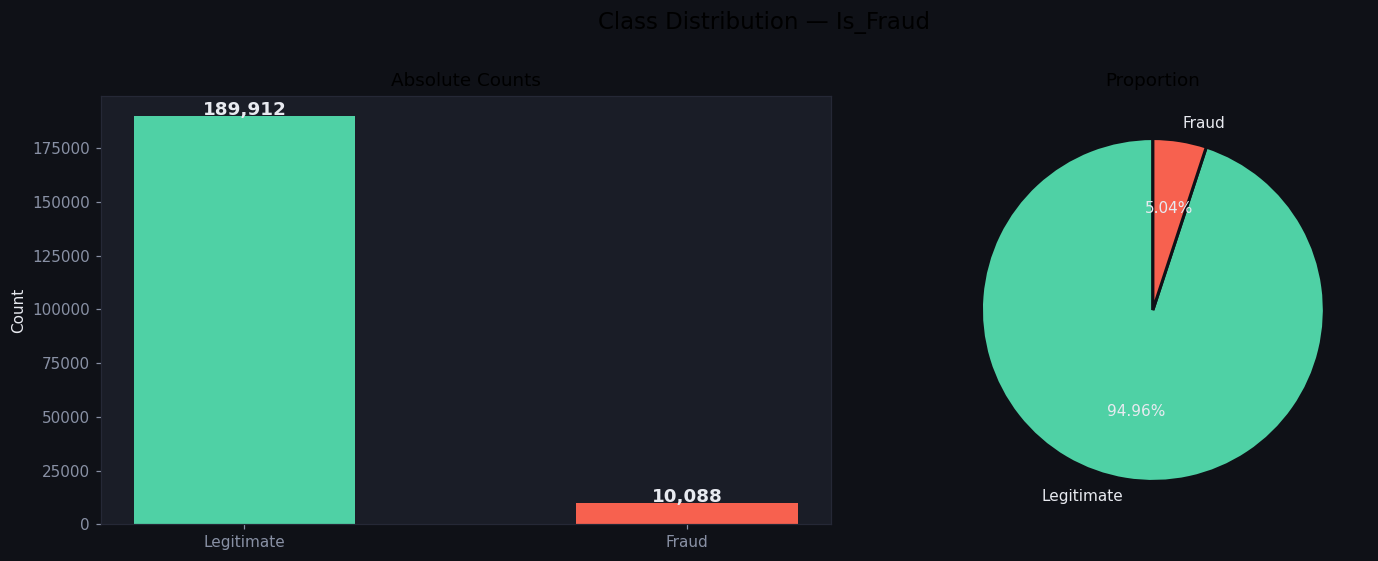

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution — Is_Fraud", fontsize=15, y=1.01)

counts = df["Is_Fraud"].value_counts()
axes[0].bar(["Legitimate", "Fraud"], counts.values,
            color=[DARK["green"], DARK["red"]], edgecolor="none", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=12,
                 color=DARK["text"], fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_title("Absolute Counts")

axes[1].pie(counts.values, labels=["Legitimate", "Fraud"],
            colors=[DARK["green"], DARK["red"]], autopct="%1.2f%%",
            startangle=90, wedgeprops={"edgecolor": DARK["bg"], "linewidth": 2},
            textprops={"color": DARK["text"]})
axes[1].set_title("Proportion")

plt.tight_layout()
plt.show()

## Amount Distribution Analysis

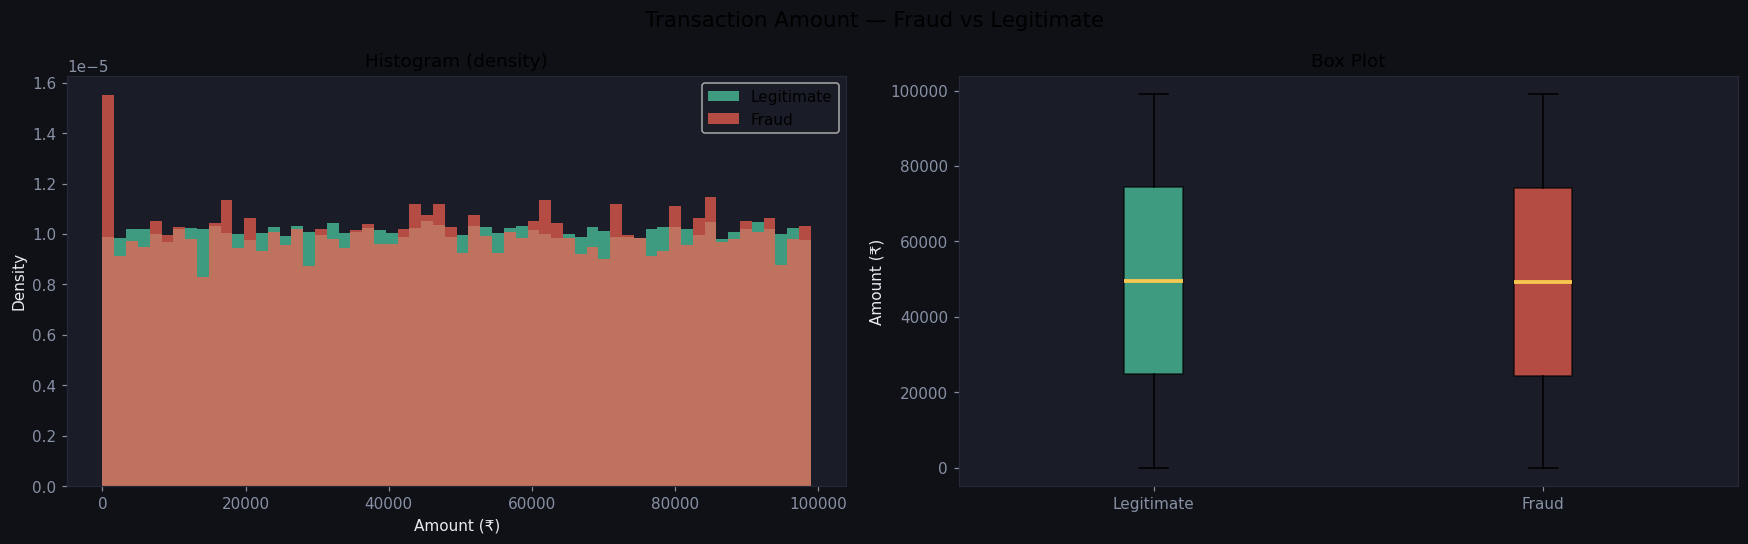

Median - Legit: ₹49,517
Median - Fraud: ₹49,163


In [6]:
fraud_amt = df[df["Is_Fraud"] == 1]["Transaction_Amount"]
legit_amt = df[df["Is_Fraud"] == 0]["Transaction_Amount"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Transaction Amount — Fraud vs Legitimate", fontsize=14)

axes[0].hist(legit_amt, bins=60, alpha=0.7, density=True,
             color=DARK["green"], label="Legitimate")
axes[0].hist(fraud_amt, bins=60, alpha=0.7, density=True,
             color=DARK["red"], label="Fraud")
axes[0].set_xlabel("Amount (₹)")
axes[0].set_ylabel("Density")
axes[0].set_title("Histogram (density)")
axes[0].legend()

bp_data = [legit_amt, fraud_amt]
bp = axes[1].boxplot(bp_data, patch_artist=True,
                     medianprops=dict(color=DARK["gold"], lw=2.5))
for patch, c in zip(bp["boxes"], [DARK["green"], DARK["red"]]):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(["Legitimate", "Fraud"])
axes[1].set_ylabel("Amount (₹)")
axes[1].set_title("Box Plot")

plt.tight_layout()
plt.show()

print(f"Median - Legit: ₹{legit_amt.median():,.0f}")
print(f"Median - Fraud: ₹{fraud_amt.median():,.0f}")

## Fraud Rate by Categorical Features

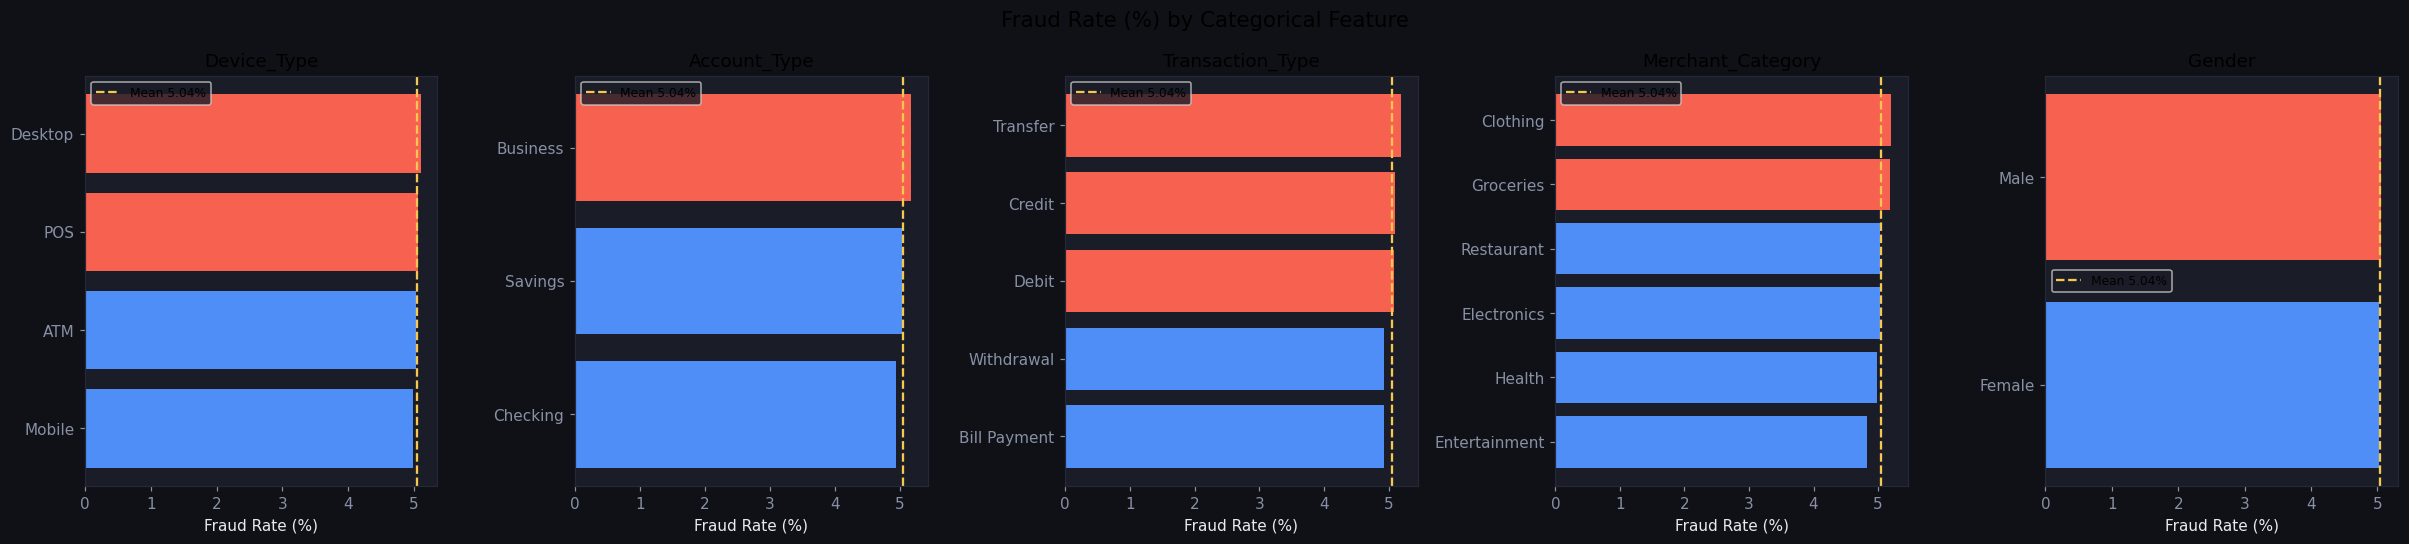

In [7]:
cat_features = ["Device_Type", "Account_Type", "Transaction_Type", "Merchant_Category", "Gender"]

fig, axes = plt.subplots(1, len(cat_features), figsize=(22, 5))
fig.suptitle("Fraud Rate (%) by Categorical Feature", fontsize=14)

for ax, col in zip(axes, cat_features):
    rates = df.groupby(col)["Is_Fraud"].mean().sort_values() * 100
    colors = [DARK["red"] if v >= rates.mean() else DARK["blue"] for v in rates.values]
    ax.barh(rates.index, rates.values, color=colors, edgecolor="none")
    ax.axvline(rates.mean(), color=DARK["gold"], ls="--", lw=1.5,
               label=f"Mean {rates.mean():.2f}%")
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Temporal Pattern Analysis

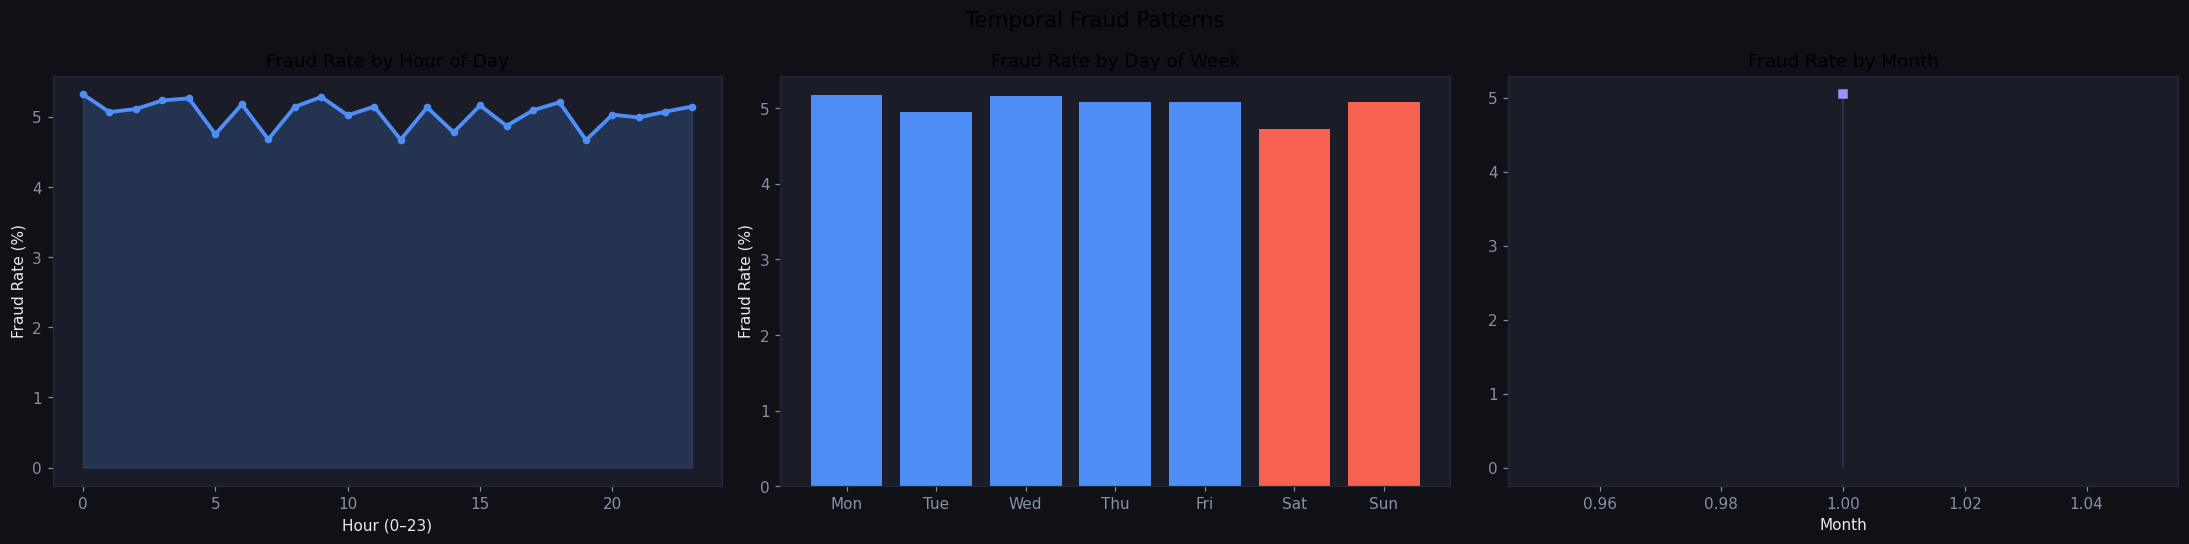

In [8]:
_date = pd.to_datetime(df["Transaction_Date"], dayfirst=True, errors="coerce")
_time = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S", errors="coerce")
_hour = _time.dt.hour
_dow = _date.dt.dayofweek
_mon = _date.dt.month

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Temporal Fraud Patterns", fontsize=14)

hourly = df.groupby(_hour)["Is_Fraud"].mean() * 100
axes[0].plot(hourly.index, hourly.values, color=DARK["blue"], lw=2.5, marker="o", ms=4)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color=DARK["blue"])
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Fraud Rate (%)")

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = df.groupby(_dow)["Is_Fraud"].mean() * 100
colors_dow = [DARK["red"] if i >= 5 else DARK["blue"] for i in range(7)]
axes[1].bar(day_labels, daily.values, color=colors_dow, edgecolor="none")
axes[1].set_title("Fraud Rate by Day of Week")
axes[1].set_ylabel("Fraud Rate (%)")

monthly = df.groupby(_mon)["Is_Fraud"].mean() * 100
axes[2].plot(monthly.index, monthly.values, color=DARK["purple"], lw=2.5, marker="s", ms=5)
axes[2].fill_between(monthly.index, monthly.values, alpha=0.2, color=DARK["purple"])
axes[2].set_title("Fraud Rate by Month")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()

## Balance vs Amount Scatter

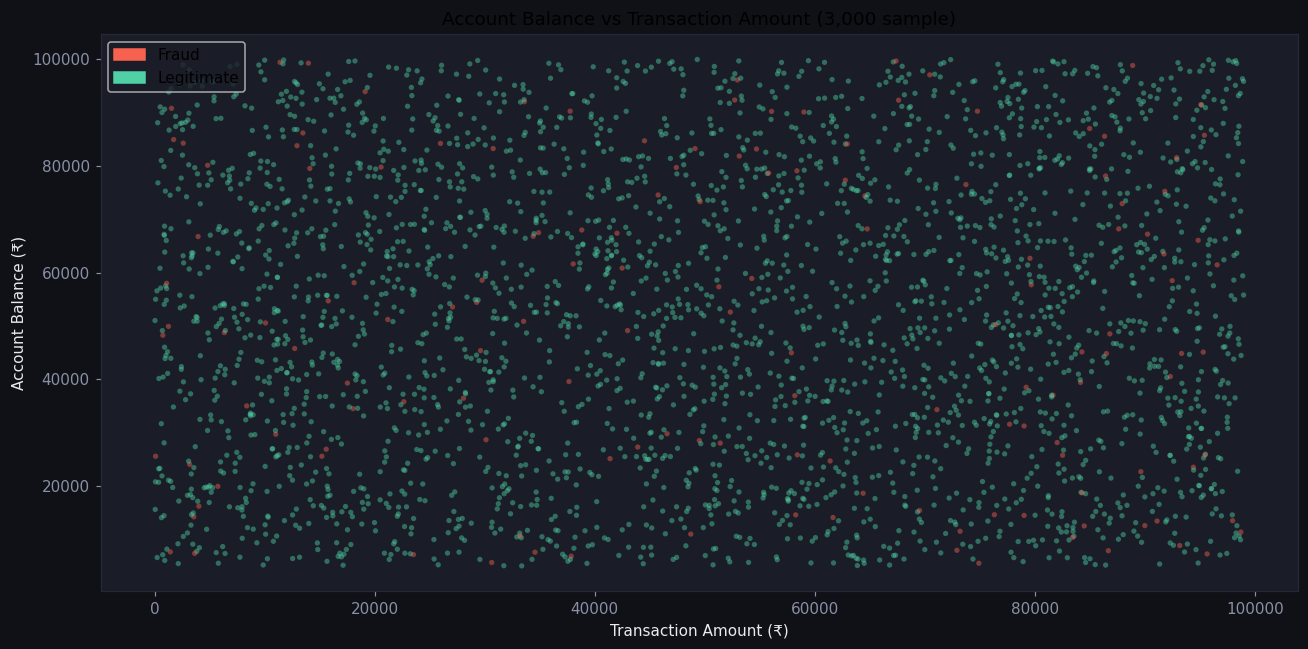

In [9]:
sample = df.sample(3000, random_state=SEED)
colors = [DARK["red"] if f else DARK["green"] for f in sample["Is_Fraud"]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(sample["Transaction_Amount"], sample["Account_Balance"],
           c=colors, alpha=0.45, s=12, edgecolors="none")
ax.set_xlabel("Transaction Amount (₹)")
ax.set_ylabel("Account Balance (₹)")
ax.set_title("Account Balance vs Transaction Amount (3,000 sample)")
legend_handles = [
    mpatches.Patch(color=DARK["red"], label="Fraud"),
    mpatches.Patch(color=DARK["green"], label="Legitimate"),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

## Save processed data

In [10]:
df.to_csv("data/data_after_eda.csv", index=False)
print(" Data successfuly saved!")

 Data successfuly saved!
